In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install transformers

In [ ]:
import numpy as np # used for handling numbers
import pandas as pd # used for handling the dataset
from sklearn.impute import SimpleImputer # used for handling missing data
from sklearn.preprocessing import LabelEncoder, OneHotEncoder # used for encoding categorical data
from sklearn.model_selection import train_test_split # used for splitting training and testing data
from sklearn.preprocessing import StandardScaler # used for feature scaling

In [ ]:
from torch import cuda
device = 'cuda' if cuda.is_available() else 'cpu'
device

'cuda'

In [ ]:
import pandas as pd
input = pd.read_excel('/content/drive/MyDrive/Minor-Project/ERC-EFR/Codebase/Bhaav-Dataset.xlsx')
val1_df = pd.read_csv('/content/drive/MyDrive/Minor-Project/ERC-EFR/Codebase/preprocessedInput.csv', encoding='utf-8')
val2_df = pd.read_csv('/content/drive/MyDrive/Minor-Project/ERC-EFR/Codebase/preprocessedValInput.csv', encoding='utf-8')

In [ ]:
input

,Sentences,Annotation
0,रमजान के पूरे तीस रोजों के बाद ईद आयी है,1
1,"कितना मनोहर, कितना सुहावना प्रभाव है",1
2,"वृक्षों पर अजीब हरियाली है, खेतों में कुछ अजीब...",1
3,"आज का सूर्य देखो, कितना प्यारा, कितना शीतल है,...",1
4,गाँव में कितनी हलचल है,1
...,...,...
20299,फिर यहाँ सर्दी हो जाती है,4
20300,दिन-भर मैं यह देखती रहती हूँ कि धूप का टुकड़ा क...,4
20301,"पार्क का कोई ऐसा कोना नहीं, जहाँ मैं घड़ी-आधा घ...",4
20302,लेकिन यह बेंच मुझे सबसे अच्छी लगती है,1


In [ ]:
input['utterance_id'] = range(1, len(input) + 1)
val1_df['utterance_id'] = range(1, len(val1_df) + 1)
val2_df['utterance_id'] = range(1, len(val2_df) + 1)

In [ ]:
train = input[['utterance_id', 'Sentences', 'Annotation']]
val1 = val1_df[['utterance_id', 'hindi_utterances', 'emotions']]
val2 = val2_df[['utterance_id', 'hindi_utterances', 'emotions']]

<Axes: >

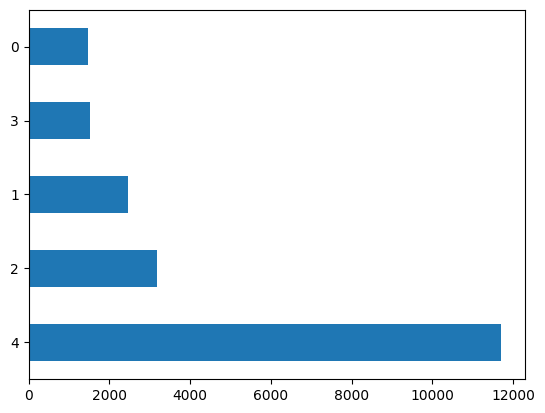

In [ ]:
train['Annotation'].value_counts().plot(kind="barh")

Anger: 0

Joy: 1

Sad: 2

Suspense: 3

Neutral: 4

In [ ]:
train.isnull().sum().sum()

0

In [ ]:
# emotions = train['emotions'].unique().tolist()
# emotions_val = val['emotions'].unique().tolist()
# emotions = [s.strip() for s in emotions ]
# emotions_val = [s.strip() for s in emotions_val ]

In [ ]:
# for key, value in enumerate(emotions):
#     print(value)

In [ ]:
NUM_LABELS= 8

id2label = {
    0: 'anger',
    1: 'joy',
    2: 'sadness',
    3: 'surprise',
    4: 'neutral',
    5: 'contempt',
    6: 'disgust',
    7: 'fear'
}

label2id = {
    'anger': 0,
    'joy': 1,
    'sadness': 2,
    'surprise': 3,
    'neutral': 4,
    'contempt': 5,
    'disgust': 6,
    'fear': 7
}


# id2label={id:label for id,label in enumerate(emotions)}

# label2id={label:id for id,label in enumerate(emotions)}

In [ ]:
label2id

{'anger': 0,
 'joy': 1,
 'sadness': 2,
 'surprise': 3,
 'neutral': 4,
 'contempt': 5,
 'disgust': 6,
 'fear': 7}

In [ ]:
id2label

{0: 'anger',
 1: 'joy',
 2: 'sadness',
 3: 'surprise',
 4: 'neutral',
 5: 'contempt',
 6: 'disgust',
 7: 'fear'}

In [ ]:
# train["labels"]=train.emotions.map(lambda x: label2id[x.strip()])
val1["labels"]=val1.emotions.map(lambda x: label2id[x.strip()])
val2["labels"]=val2.emotions.map(lambda x: label2id[x.strip()])

<ipython-input-14-be8c359a6e8a>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val1["labels"]=val1.emotions.map(lambda x: label2id[x.strip()])
<ipython-input-14-be8c359a6e8a>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val2["labels"]=val2.emotions.map(lambda x: label2id[x.strip()])


In [ ]:
import torch
import transformers
from transformers import BertTokenizer, BertForSequenceClassification

tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-cased')
model = BertForSequenceClassification.from_pretrained("bert-base-multilingual-cased", num_labels=NUM_LABELS, id2label=id2label, label2id=label2id)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
model.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(119547, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12

In [ ]:
train.Annotation.unique()

array([1, 4, 0, 2, 3])

In [ ]:
# SIZE= train.shape[0]

train_texts= list(train.Sentences)

val_texts=   list(val1.hindi_utterances)

test_texts=   list(val2.hindi_utterances)

# test_texts=  list(train.hindi_utterances[(3*SIZE)//4:])

train_labels= list(train.Annotation)

val_labels=   list(val1.labels)

test_labels=   list(val2.labels)

# test_labels=  list(train.labels[(3*SIZE)//4:])

In [ ]:
len(train_texts), len(val_texts), len(test_texts)

(20304, 8506, 1354)

In [ ]:
train_encodings = tokenizer(train_texts, truncation=True, padding=True)
val_encodings  = tokenizer(val_texts, truncation=True, padding=True)
test_encodings = tokenizer(test_texts, truncation=True, padding=True)

In [ ]:
from torch.utils.data import Dataset

class DataLoader(Dataset):
    """
    Custom Dataset class for handling tokenized text data and corresponding labels.
    Inherits from torch.utils.data.Dataset.
    """
    def __init__(self, encodings, labels):
        """
        Initializes the DataLoader class with encodings and labels.

        Args:
            encodings (dict): A dictionary containing tokenized input text data
                              (e.g., 'input_ids', 'token_type_ids', 'attention_mask').
            labels (list): A list of integer labels for the input text data.
        """
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        """
        Returns a dictionary containing tokenized data and the corresponding label for a given index.

        Args:
            idx (int): The index of the data item to retrieve.

        Returns:
            item (dict): A dictionary containing the tokenized data and the corresponding label.
        """
        # Retrieve tokenized data for the given index
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        # Add the label for the given index to the item dictionary
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        """
        Returns the number of data items in the dataset.

        Returns:
            (int): The number of data items in the dataset.
        """
        return len(self.labels)

In [ ]:
train_dataloader = DataLoader(train_encodings, train_labels)

val_dataloader = DataLoader(val_encodings, val_labels)

test_dataset = DataLoader(test_encodings, test_labels)

In [ ]:
from transformers import TrainingArguments, Trainer

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(pred):
    """
    Computes accuracy, F1, precision, and recall for a given set of predictions.

    Args:
        pred (obj): An object containing label_ids and predictions attributes.
            - label_ids (array-like): A 1D array of true class labels.
            - predictions (array-like): A 2D array where each row represents
              an observation, and each column represents the probability of
              that observation belonging to a certain class.

    Returns:
        dict: A dictionary containing the following metrics:
            - Accuracy (float): The proportion of correctly classified instances.
            - F1 (float): The macro F1 score, which is the harmonic mean of precision
              and recall. Macro averaging calculates the metric independently for
              each class and then takes the average.
            - Precision (float): The macro precision, which is the number of true
              positives divided by the sum of true positives and false positives.
            - Recall (float): The macro recall, which is the number of true positives
              divided by the sum of true positives and false negatives.
    """
    # Extract true labels from the input object
    labels = pred.label_ids

    # Obtain predicted class labels by finding the column index with the maximum probability
    preds = pred.predictions.argmax(-1)

    # Compute macro precision, recall, and F1 score using sklearn's precision_recall_fscore_support function
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro')

    # Calculate the accuracy score using sklearn's accuracy_score function
    acc = accuracy_score(labels, preds)

    # Return the computed metrics as a dictionary
    return {
        'Accuracy': acc,
        'F1': f1,
        'Precision': precision,
        'Recall': recall
    }

In [ ]:
!pip install transformers[torch]

In [ ]:
logging_steps = len(train_dataloader) // 32

training_args = TrainingArguments(
    # The output directory where the model predictions and checkpoints will be written
    output_dir='/content/drive/MyDrive/Minor-Project/ERC-EFR/Codebase/Task1_Predictions_Bhaav',
    # do_train=True,
    # do_eval=True,
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    # Number of steps used for a linear warmup
    # warmup_steps=0,
    weight_decay=0.01,
    # logging_strategy='steps',
   # TensorBoard log directory
    # logging_dir='/content/drive/MyDrive/Minor-Project/ERC-EFR/Codebase/Task1_Predictions_Bhaav/multi-class-logs',
    evaluation_strategy="epoch",
    # eval_steps=50,
    save_strategy="epoch",
    logging_steps=logging_steps,
    # fp16=True,
    # load_best_model_at_end=True
)

In [ ]:
trainer = Trainer(
    # the pre-trained model that will be fine-tuned
    model=model,
     # training arguments that we defined above
    args=training_args,
    train_dataset=train_dataloader,
    eval_dataset=val_dataloader,
    compute_metrics= compute_metrics
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,1.261800,2.206405,0.459558,0.078715,0.057445,0.125000
2,1.241200,2.365365,0.459558,0.078715,0.057445,0.125000
3,1.218600,2.343876,0.459558,0.078715,0.057445,0.125000


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


TrainOutput(global_step=1905, training_loss=1.240298293706939, metrics={'train_runtime': 3251.9098, 'train_samples_per_second': 18.731, 'train_steps_per_second': 0.586, 'total_flos': 7669401515516160.0, 'train_loss': 1.240298293706939, 'epoch': 3.0})

In [ ]:
q=[trainer.evaluate(eval_dataset=train) for train in [train_dataloader, val_dataloader, test_dataset]]

pd.DataFrame(q, index=["train","val", "test"]).iloc[:,:5]

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


,eval_loss,eval_Accuracy,eval_F1,eval_Precision,eval_Recall
train,1.198382,0.576093,0.146208,0.115219,0.200
val,2.343876,0.459558,0.078715,0.057445,0.125
test,2.291718,0.467504,0.079643,0.058438,0.125


In [ ]:
def predict(text):
    """
    Predicts the class label for a given input text

    Args:
        text (str): The input text for which the class label needs to be predicted.

    Returns:
        probs (torch.Tensor): Class probabilities for the input text.
        pred_label_idx (torch.Tensor): The index of the predicted class label.
        pred_label (str): The predicted class label.
    """
    # Tokenize the input text and move tensors to the GPU if available
    inputs = tokenizer(text, padding=True, truncation=True, max_length=512, return_tensors="pt").to("cuda")

    # Get model output (logits)
    outputs = model(**inputs)

    probs = outputs[0].softmax(1)
    """ Explanation outputs: The BERT model returns a tuple containing the output logits (and possibly other elements depending on the model configuration). In this case, the output logits are the first element in the tuple, which is why we access it using outputs[0].

    outputs[0]: This is a tensor containing the raw output logits for each class. The shape of the tensor is (batch_size, num_classes) where batch_size is the number of input samples (in this case, 1, as we are predicting for a single input text) and num_classes is the number of target classes.

    softmax(1): The softmax function is applied along dimension 1 (the class dimension) to convert the raw logits into class probabilities. Softmax normalizes the logits so that they sum to 1, making them interpretable as probabilities. """

    # Get the index of the class with the highest probability
    # argmax() finds the index of the maximum value in the tensor along a specified dimension.
    # By default, if no dimension is specified, it returns the index of the maximum value in the flattened tensor.
    pred_label_idx = probs.argmax()

    # Now map the predicted class index to the actual class label
    # Since pred_label_idx is a tensor containing a single value (the predicted class index),
    # the .item() method is used to extract the value as a scalar
    pred_label = model.config.id2label[pred_label_idx.item()]

    # return probs, pred_label_idx, pred_label
    return pred_label

In [ ]:
model_path = "bert-base-multilingual-cased"
trainer.save_model(model_path)
tokenizer.save_pretrained(model_path)

('bert-base-multilingual-cased/tokenizer_config.json',
 'bert-base-multilingual-cased/special_tokens_map.json',
 'bert-base-multilingual-cased/vocab.txt',
 'bert-base-multilingual-cased/added_tokens.json')

In [ ]:
results = []
for index, row in val2.iterrows():
    result = predict(row['hindi_utterances'])
    results.append(result)

val2['predicted_emotions'] = results

<ipython-input-32-bbed3756658d>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val2['predicted_emotions'] = results


In [ ]:
val2

,utterance_id,hindi_utterances,emotions,labels,predicted_emotions
0,1,ये क्य कर् रह है रोसेश्? भरत् तेर देश्! भर्तिय...,neutral,4,neutral
1,2,हहह खत् पध् ले रोसेश् बब्य् ओर् पध्ने दे हमेन्...,neutral,4,neutral
2,3,"कवित अच्चि है लेकिन् खयल् अच्च नहिन् है, विल्ल...",neutral,4,neutral
3,4,"गलत् है, पर् मोम्म ने तुम्से कह थ कि दो बर् ब्...",contempt,5,neutral
4,5,गलत् थ पेर्,neutral,4,neutral
...,...,...,...,...,...
1349,1350,सहिल् सहिल् सहिल्। सिर्फ़् ४ दिन् बचे है ओर् सर...,fear,7,neutral
1350,1351,हान् लेकिन् मोम् उन्न् चरो मे से किसि एक् को फ़...,neutral,4,neutral
1351,1352,मुम्म्य् जि को तो उन्मे से कोइ पसन्द् न्हि है,sadness,2,neutral
1352,1353,रोसेश् को?,neutral,4,neutral


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(val2.emotions,val2.predicted_emotions,digits=4))

              precision    recall  f1-score   support

       anger     0.0000    0.0000    0.0000       118
    contempt     0.0000    0.0000    0.0000        74
     disgust     0.0000    0.0000    0.0000        21
        fear     0.0000    0.0000    0.0000        88
         joy     0.0000    0.0000    0.0000       228
     neutral     0.4675    1.0000    0.6371       633
     sadness     0.0000    0.0000    0.0000       126
    surprise     0.0000    0.0000    0.0000        66

    accuracy                         0.4675      1354
   macro avg     0.0584    0.1250    0.0796      1354
weighted avg     0.2186    0.4675    0.2979      1354



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
# import torch
# import transformers
# from transformers import BertTokenizer, BertForSequenceClassification, pipeline

# model_path = "bert-base-multilingual-cased"
# model = BertForSequenceClassification.from_pretrained(model_path)
# tokenizer= BertTokenizer.from_pretrained(model_path)
# nlp = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)

In [ ]:
val2.to_csv("/content/drive/MyDrive/Minor-Project/ERC-EFR/Codebase/mBERT_Bhaav_predictions.csv", index=False)